## Data Aggrigation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_train = pd.read_csv('drugsComTrain_raw.csv')
df_test = pd.read_csv('drugsComTest_raw.csv')

In [4]:
data = pd.concat([df_train,df_test])

In [6]:
df = data.copy()

In [14]:
df.sample(10)

,uniqueID,drugName,condition,review,rating,date,usefulCount
29812,158488,Methylphenidate,ADHD,"""I have been taking conserta 54 and 36 (legall...",9,15-May-15,23
8190,54745,Bupropion / naltrexone,Obesity,"""Female age 40 height 5&#039;2 305lbs. Started...",7,5-Apr-17,68
51136,167473,Levonorgestrel,Birth Control,"""I had Skyla placed about 4 months ago. I have...",8,1-Mar-16,0
59864,15039,Ethinyl estradiol / norethindrone,Birth Control,"""At the beginning, it caused a LOT of nausea. ...",7,12-Jul-17,0
20304,156953,Movantik,Opioid-Induced Constipation,"""just wondering why sometimes it works and oth...",8,11-Apr-17,10
120995,158924,TriNessa,Birth Control,"""My first month was fine! I am a very emotiona...",1,12-Oct-17,1
130319,171501,Wellbutrin,Depression,"""If I Wellbutrin was in my life few years ago ...",10,3-Jan-14,98
39588,209576,Sipuleucel-T,Prostate Cance,"""Before starting Provenge my PSA was at 4.85 a...",1,23-Dec-16,0
58154,93106,Vortioxetine,Depression,"""I&#039;m on brintellix for month and a half n...",10,24-Apr-16,110
455,107729,Implanon,Birth Control,"""It&#039;s a great birth control... but only b...",3,2-Feb-10,1


From initial observation, I can say that condition and review column consists of invalid char so it need to be cleaned

## Basic anaysis

In [17]:
df.shape

(215063, 7)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215063 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     215063 non-null  int64 
 1   drugName     215063 non-null  object
 2   condition    213869 non-null  object
 3   review       215063 non-null  object
 4   rating       215063 non-null  int64 
 5   date         215063 non-null  object
 6   usefulCount  215063 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 13.1+ MB


Data column is in string format. It need to be converted into date format

In [8]:
df.describe()

,uniqueID,rating,usefulCount
count,215063.000000,215063.000000,215063.000000
mean,116039.364814,6.990008,28.001004
std,67007.913366,3.275554,36.346069
min,0.000000,1.000000,0.000000
25%,58115.500000,5.000000,6.000000
50%,115867.000000,8.000000,16.000000
75%,173963.500000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [15]:
df.isnull().sum()

uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

There are 1194 rows are null values in condition column

In [20]:
df.corr(numeric_only=True)

,uniqueID,rating,usefulCount
uniqueID,1.000000,0.016336,0.017567
rating,0.016336,1.000000,0.234860
usefulCount,0.017567,0.234860,1.000000


## Univariate analysis

In [23]:
from wordcloud import WordCloud, STOPWORDS

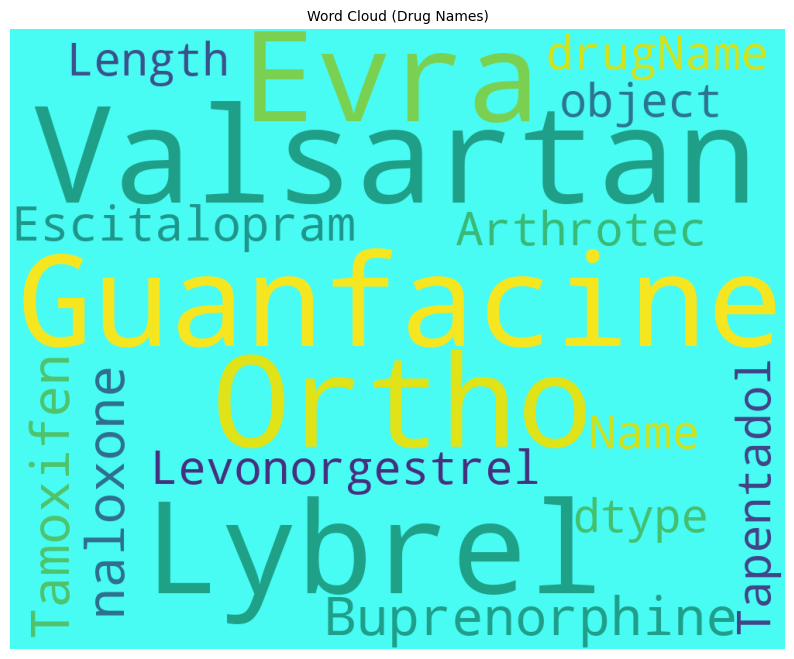

In [74]:
wordcloud = WordCloud(stopwords=set(STOPWORDS),
                      background_color='rgb(73, 252, 243)',
                      height=800,
                      width=1000
).generate(str(df['drugName']))


plt.figure(figsize=(10,10))
plt.title('Word Cloud (Drug Names)', fontsize = 10)
plt.axis("off")
plt.imshow(wordcloud)

The above cloud includes the metadata as well like dtype, Length etc. Because the str(pd.Series) includes meta data as well

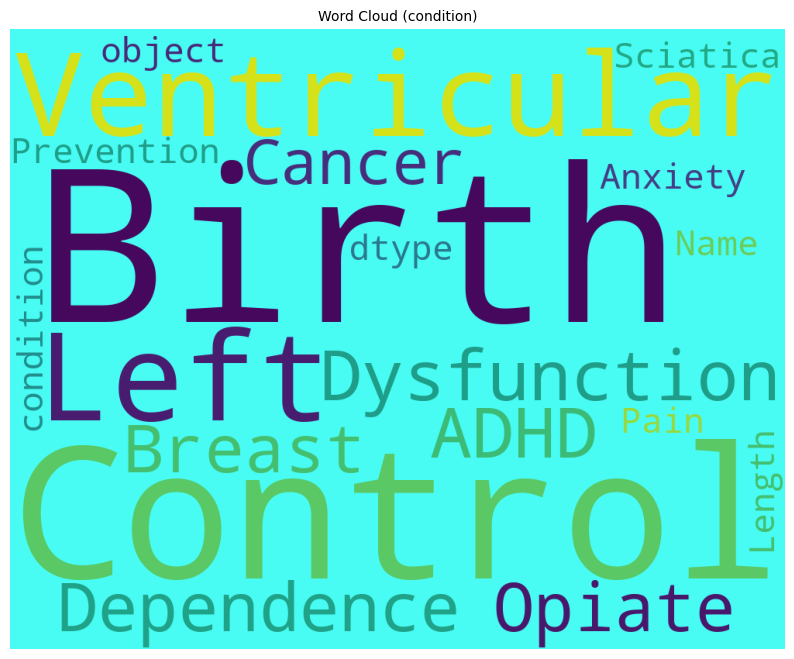

In [73]:
wordcloud = WordCloud(stopwords=set(STOPWORDS),
                      background_color='rgb(73, 252, 243)',
                      height=800,
                      width=1000
).generate(str(df['condition']))


plt.figure(figsize=(10,10))
plt.title('Word Cloud (condition)', fontsize = 10)
plt.axis("off")
plt.imshow(wordcloud)

Most of the times, we can see the birth control, ADHD, Ventricular etc

<Axes: ylabel='count'>

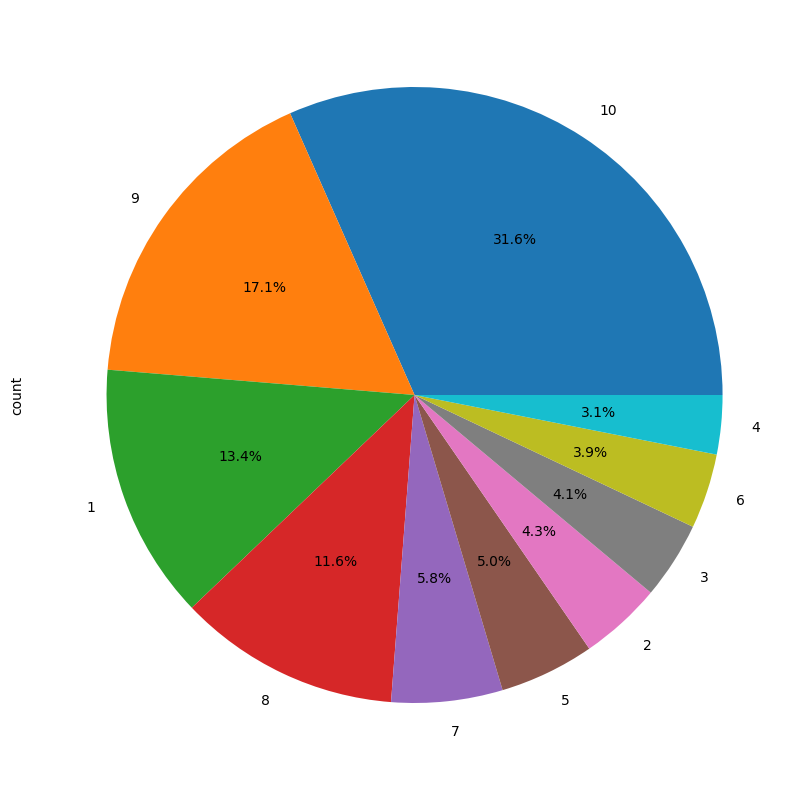

In [53]:
df['rating'].value_counts().plot(kind='pie',autopct='%1.1f%%')

<Axes: xlabel='rating', ylabel='Density'>

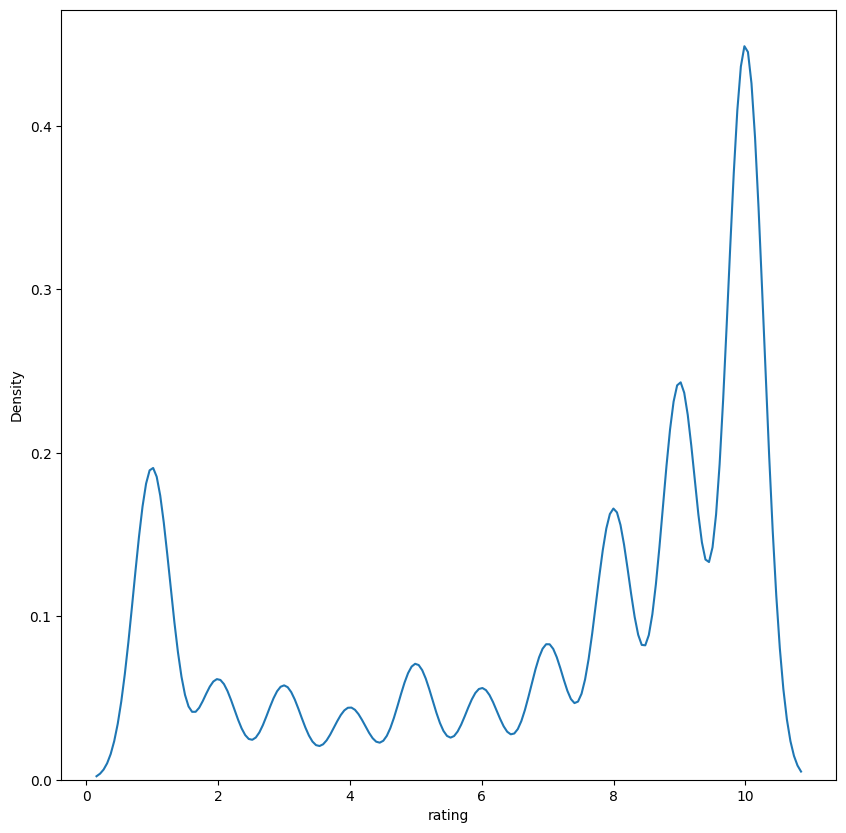

In [72]:
sns.kdeplot(df['rating'])

Most of the ratings are higher ratings ie 10, 9, 8. Some drugs about 13% also got worst rating 1

In [61]:
print((df['rating'] > 5).sum())
print((df['rating'] <= 5).sum())

150768
64295


Data is imbalance by a huge difference. May be the data includes so much of positive drugs. Hence the model may not perform well on negative drugs so well

## Bivariante analysis

C:\Users\91939\AppData\Local\Temp\ipykernel_24084\3663489246.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


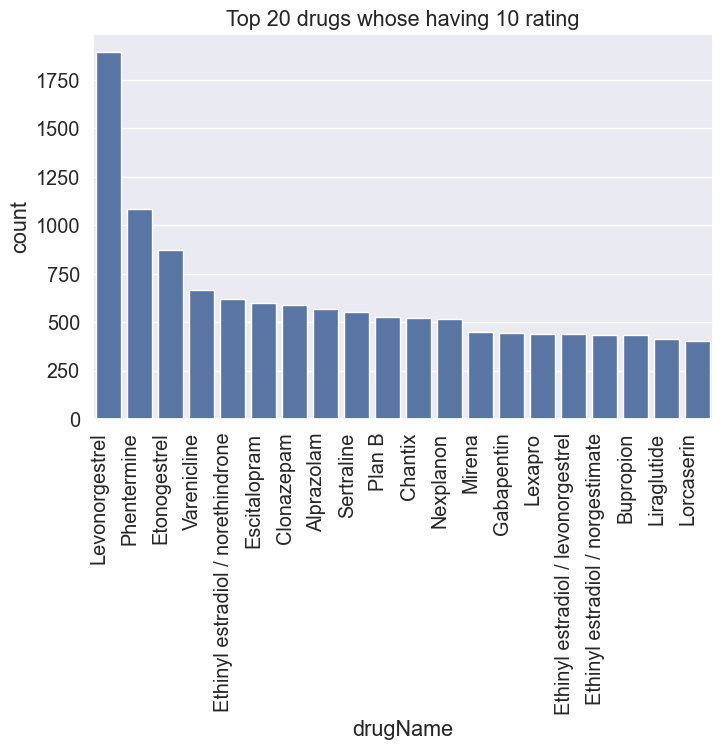

In [113]:
top_drugs_10 = df[df['rating'] == 10]['drugName'].value_counts().head(20)
bar=sns.barplot(top_drugs_10)
bar.set_title('Top 20 drugs whose having 10 rating')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [17, 5]

C:\Users\91939\AppData\Local\Temp\ipykernel_24084\1902578690.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


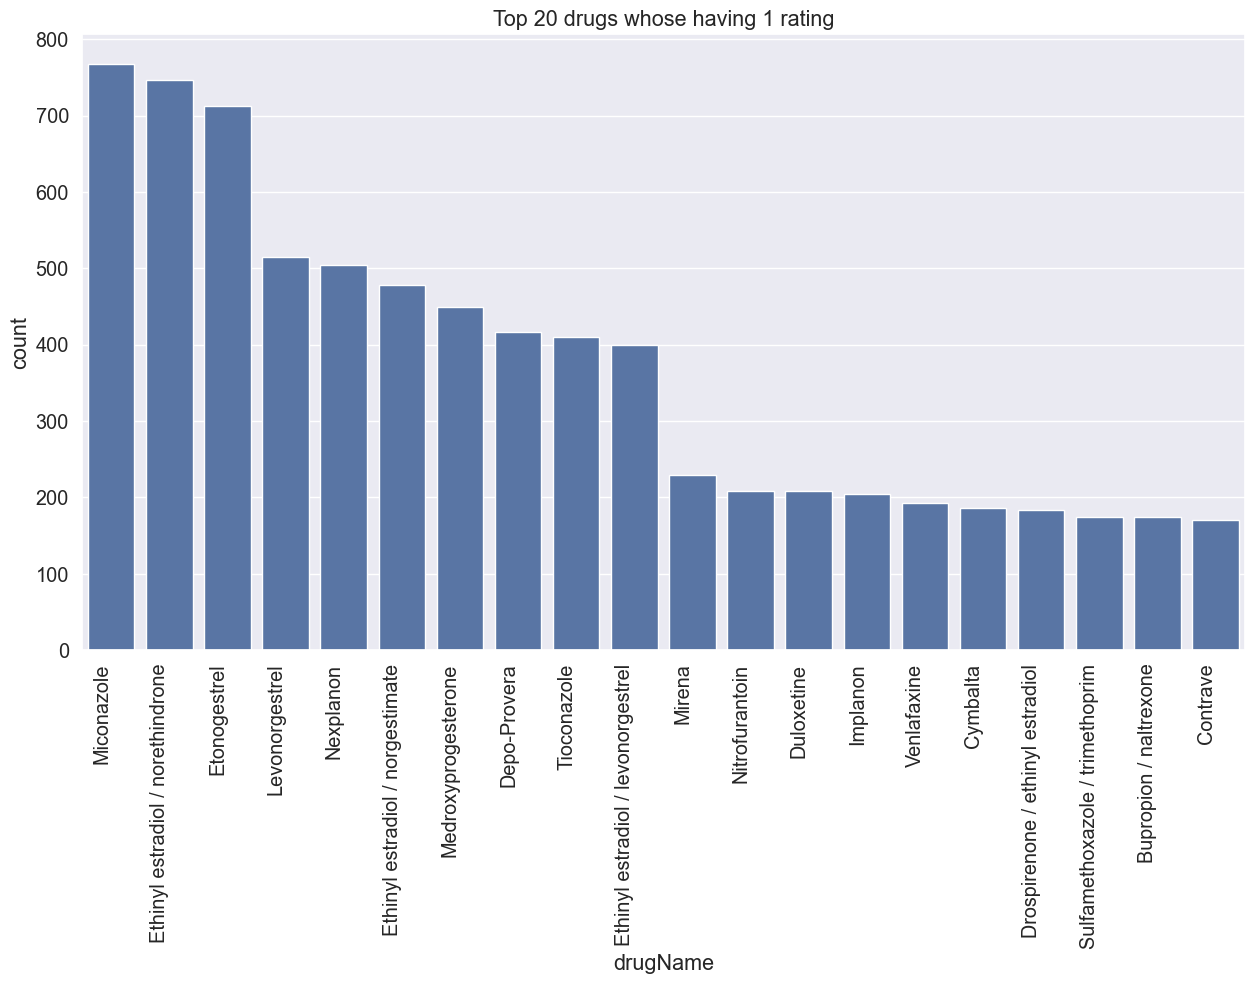

In [110]:
top_drugs_1 = df[df['rating'] == 1]['drugName'].value_counts().head(20)
bar=sns.barplot(top_drugs_1)
bar.set_title('Top 20 drugs whose having 1 rating')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [8, 8]

C:\Users\91939\AppData\Local\Temp\ipykernel_24084\4106974381.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')


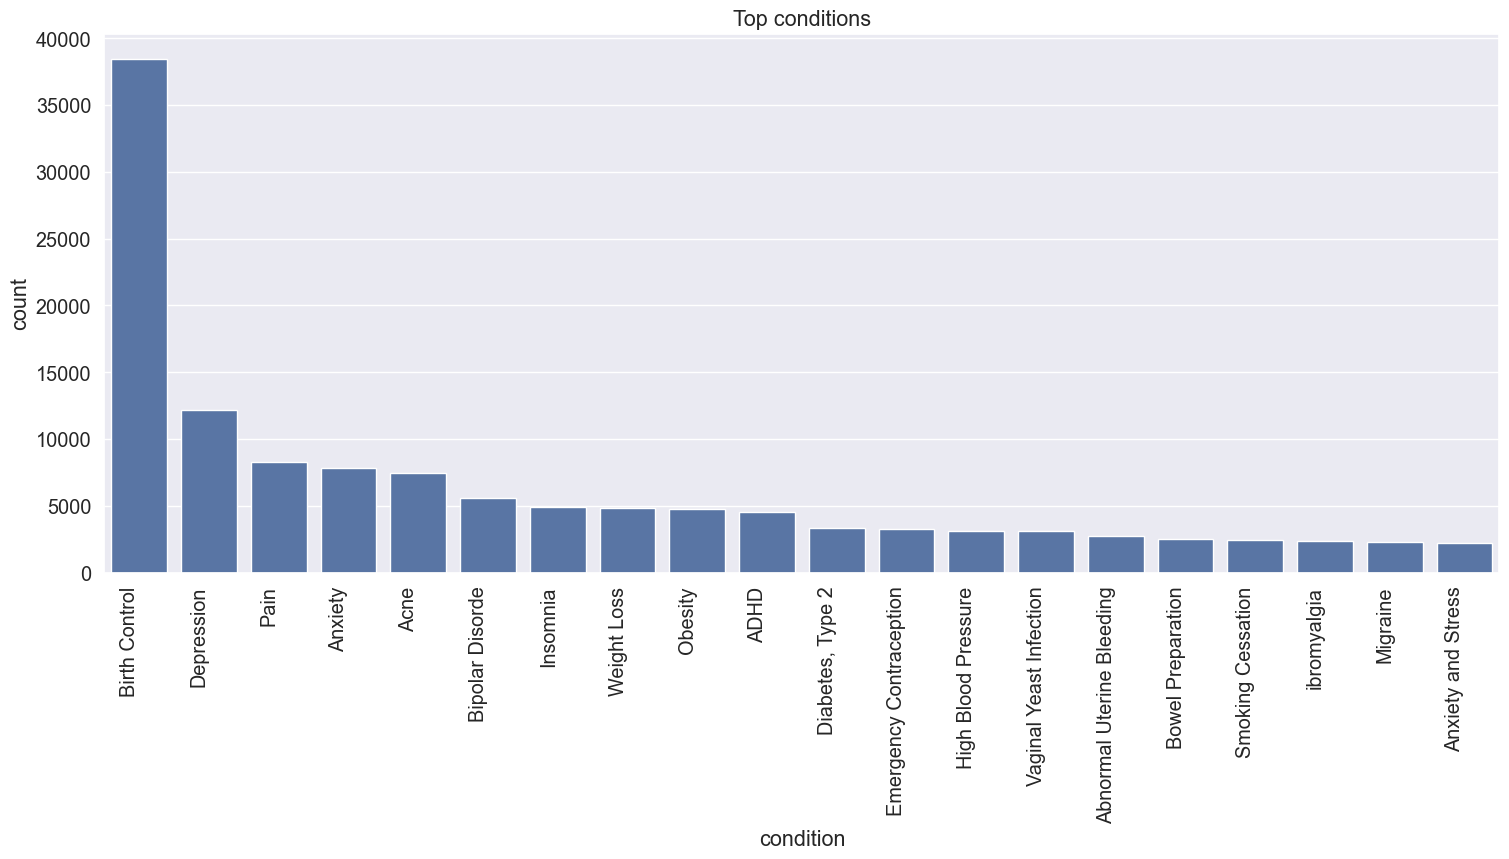

In [102]:
top_conditions = df['condition'].value_counts().head(20)
bar=sns.barplot(top_conditions)
bar.set_title('Top conditions')
bar.set_xticklabels(bar.get_xticklabels(), rotation=90, ha='right')
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [5, 5]

## Text preprocessing